In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input/competitions/shopee-product-matching"):
    if files:
        print(root)
        print("Number of files:", len(files))
        print("Sample:", files[:5])

/kaggle/input/competitions/shopee-product-matching
Number of files: 3
Sample: ['sample_submission.csv', 'train.csv', 'test.csv']
/kaggle/input/competitions/shopee-product-matching/train_images
Number of files: 32412
Sample: ['07c251a26b8266c85730ab8d870f1356.jpg', '36dc46d97cdaa7622793e7016976da46.jpg', 'b3c7b96aeb0398b152fa5984260a6c57.jpg', '1bd82215202e4e261a1eb8311473c450.jpg', '0b2c815972b87908af3652d2986a55a7.jpg']
/kaggle/input/competitions/shopee-product-matching/test_images
Number of files: 3
Sample: ['0006c8e5462ae52167402bac1c2e916e.jpg', '0008377d3662e83ef44e1881af38b879.jpg', '0007585c4d0f932859339129f709bfdc.jpg']


In [2]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cpu
Torchvision: 0.26.0+cpu
CUDA available: False


In [3]:
import torch
import torchvision.models as models

weights = models.ResNet50_Weights.DEFAULT

resnet = models.resnet50(weights=weights)

# Remove the final classification layer
resnet.fc = torch.nn.Identity()

resnet.eval()

print(resnet)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 151MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [6]:
import pandas as pd

train_path = "/kaggle/input/competitions/shopee-product-matching/train.csv"
train = pd.read_csv(train_path)

print(train.shape)

(34250, 5)


In [7]:
from PIL import Image
import torch

preprocess = weights.transforms()

image_path = "/kaggle/input/competitions/shopee-product-matching/train_images/" + train.iloc[0]["image"]

image = Image.open(image_path).convert("RGB")

image_tensor = preprocess(image).unsqueeze(0)

with torch.no_grad():
    embedding = resnet(image_tensor)

print("Image tensor shape:", image_tensor.shape)
print("Embedding shape:", embedding.shape)

Image tensor shape: torch.Size([1, 3, 224, 224])
Embedding shape: torch.Size([1, 2048])


In [8]:
import time
from PIL import Image
import torch

image_dir = "/kaggle/input/competitions/shopee-product-matching/train_images/"

sample_images = train["image"].iloc[:16].tolist()

batch = []

for filename in sample_images:
    image = Image.open(image_dir + filename).convert("RGB")
    batch.append(preprocess(image))

batch = torch.stack(batch)

print("Batch shape:", batch.shape)

start = time.time()

with torch.no_grad():
    batch_embeddings = resnet(batch)

end = time.time()

print("Embedding shape:", batch_embeddings.shape)
print("Time taken:", round(end - start, 2), "seconds")

Batch shape: torch.Size([16, 3, 224, 224])
Embedding shape: torch.Size([16, 2048])
Time taken: 2.2 seconds


In [9]:
unique_images = train["image"].unique()

print("Total listings:", len(train))
print("Unique images:", len(unique_images))

Total listings: 34250
Unique images: 32412


In [11]:
import numpy as np

np.random.seed(42)

sample_images = np.random.choice(
    unique_images,
    size=5000,
    replace=False
)

print("Sampled images:", len(sample_images))

Sampled images: 5000


In [13]:
from tqdm.auto import tqdm
import numpy as np

image_dir = "/kaggle/input/competitions/shopee-product-matching/train_images/"

batch_size = 16
sample_embeddings = []

for start in tqdm(range(0, len(sample_images), batch_size)):
    
    batch_files = sample_images[start:start + batch_size]
    batch = []
    
    for filename in batch_files:
        image = Image.open(image_dir + filename).convert("RGB")
        batch.append(preprocess(image))
    
    batch = torch.stack(batch)
    
    with torch.no_grad():
        embeddings = resnet(batch)
    
    sample_embeddings.append(embeddings.numpy())

sample_embeddings = np.vstack(sample_embeddings)

print("Embedding shape:", sample_embeddings.shape)

  0%|          | 0/313 [00:00<?, ?it/s]

Embedding shape: (5000, 2048)


In [14]:
image_to_index = {
    filename: i
    for i, filename in enumerate(sample_images)
}

image_info = train[train["image"].isin(sample_images)][
    ["image", "label_group"]
].drop_duplicates()

image_info = image_info.copy()
image_info["embedding_index"] = image_info["image"].map(image_to_index)

print("Images with embeddings:", len(image_info))
print(image_info.head())

Images with embeddings: 5009
                                   image  label_group  embedding_index
6   00144a49c56599d45354a1c28104c039.jpg   1835033137             2744
8   0019a3c6755a194cb2e2c12bfc63972e.jpg   2359912463             4420
32  004e512a55c80c07ae0684c58f5fcfd9.jpg   4266903097             4756
35  0052b0b2e8233836f2875a14a9808b92.jpg   1632207687             3576
36  005742b269e0ea4b352235b084e88eb4.jpg   2653016647             2107


In [15]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Positive pairs: same product group
positive_pairs = []

for group, group_data in image_info.groupby("label_group"):
    indices = group_data["embedding_index"].tolist()
    
    if len(indices) >= 2:
        for i in range(len(indices)):
            for j in range(i + 1, len(indices)):
                positive_pairs.append((indices[i], indices[j], 1))

positive_pairs = pd.DataFrame(
    positive_pairs,
    columns=["idx1", "idx2", "label"]
)

print("Positive pairs:", len(positive_pairs))

Positive pairs: 1605


In [16]:
negative_pairs = []

all_indices = image_info["embedding_index"].tolist()
all_groups = image_info["label_group"].tolist()

while len(negative_pairs) < len(positive_pairs):
    
    i, j = np.random.choice(all_indices, 2, replace=False)
    
    group_i = image_info.loc[
        image_info["embedding_index"] == i, "label_group"
    ].iloc[0]
    
    group_j = image_info.loc[
        image_info["embedding_index"] == j, "label_group"
    ].iloc[0]
    
    if group_i != group_j:
        negative_pairs.append((i, j, 0))

negative_pairs = pd.DataFrame(
    negative_pairs,
    columns=["idx1", "idx2", "label"]
)

print("Negative pairs:", len(negative_pairs))

Negative pairs: 1605


In [17]:
from sklearn.metrics.pairwise import cosine_similarity

image_pairs = pd.concat(
    [positive_pairs, negative_pairs],
    ignore_index=True
)

similarities = []

for _, row in image_pairs.iterrows():
    emb1 = sample_embeddings[int(row["idx1"])].reshape(1, -1)
    emb2 = sample_embeddings[int(row["idx2"])].reshape(1, -1)
    
    similarity = cosine_similarity(emb1, emb2)[0][0]
    similarities.append(similarity)

image_pairs["similarity"] = similarities

print(image_pairs.head())
print("Total pairs:", len(image_pairs))

   idx1  idx2  label  similarity
0    39   106      1    0.997909
1  1410  2815      1    0.374557
2  3900  3116      1    0.709025
3  2371  4108      1    0.434359
4   718  1322      1    0.864178
Total pairs: 3210


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

y_true = image_pairs["label"]

threshold_results = []

for threshold in np.arange(0.1, 1.0, 0.05):
    
    predictions = (
        image_pairs["similarity"] >= threshold
    ).astype(int)
    
    threshold_results.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions),
        "recall": recall_score(y_true, predictions),
        "f1": f1_score(y_true, predictions)
    })

threshold_df_image = pd.DataFrame(threshold_results)

best_row = threshold_df_image.loc[
    threshold_df_image["f1"].idxmax()
]

print(threshold_df_image)
print("\nBest threshold:")
print(best_row)

    threshold  accuracy  precision    recall        f1
0        0.10  0.537383   0.519430  0.999377  0.683571
1        0.15  0.615888   0.565585  0.999377  0.722360
2        0.20  0.714019   0.637565  0.991900  0.776207
3        0.25  0.804984   0.724233  0.985047  0.834741
4        0.30  0.866978   0.804550  0.969470  0.879344
5        0.35  0.905919   0.870803  0.953271  0.910173
6        0.40  0.914953   0.907589  0.923988  0.915715
7        0.45  0.917757   0.946108  0.885981  0.915058
8        0.50  0.894704   0.967528  0.816822  0.885811
9        0.55  0.857321   0.981528  0.728349  0.836195
10       0.60  0.814019   0.988372  0.635514  0.773606
11       0.65  0.771340   0.994325  0.545794  0.704747
12       0.70  0.731153   0.997319  0.463551  0.632922
13       0.75  0.685047   0.996656  0.371340  0.541080
14       0.80  0.647352   1.000000  0.294704  0.455245
15       0.85  0.623988   1.000000  0.247975  0.397404
16       0.90  0.595016   1.000000  0.190031  0.319372
17       0

In [19]:
import torchvision.models as models
import torch

weights18 = models.ResNet18_Weights.DEFAULT

resnet18 = models.resnet18(weights=weights18)
resnet18.fc = torch.nn.Identity()
resnet18.eval()

preprocess18 = weights18.transforms()

print(resnet18)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 131MB/s] 


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [20]:
import time

batch = []

for filename in sample_images[:16]:
    image = Image.open(image_dir + filename).convert("RGB")
    batch.append(preprocess18(image))

batch = torch.stack(batch)

start = time.time()

with torch.no_grad():
    test_embeddings18 = resnet18(batch)

end = time.time()

print("Batch shape:", batch.shape)
print("Embedding shape:", test_embeddings18.shape)
print("Time taken:", round(end - start, 2), "seconds")

Batch shape: torch.Size([16, 3, 224, 224])
Embedding shape: torch.Size([16, 512])
Time taken: 1.12 seconds


In [21]:
sample_embeddings18 = []

for start in tqdm(range(0, len(sample_images), batch_size)):
    
    batch_files = sample_images[start:start + batch_size]
    batch = []
    
    for filename in batch_files:
        image = Image.open(image_dir + filename).convert("RGB")
        batch.append(preprocess18(image))
    
    batch = torch.stack(batch)
    
    with torch.no_grad():
        embeddings = resnet18(batch)
    
    sample_embeddings18.append(embeddings.numpy())

sample_embeddings18 = np.vstack(sample_embeddings18)

print("ResNet18 embedding shape:", sample_embeddings18.shape)

  0%|          | 0/313 [00:00<?, ?it/s]

ResNet18 embedding shape: (5000, 512)


In [22]:
similarities18 = []

for _, row in image_pairs.iterrows():
    emb1 = sample_embeddings18[int(row["idx1"])].reshape(1, -1)
    emb2 = sample_embeddings18[int(row["idx2"])].reshape(1, -1)
    
    similarity = cosine_similarity(emb1, emb2)[0][0]
    similarities18.append(similarity)

image_pairs["similarity18"] = similarities18

print(image_pairs.head())

   idx1  idx2  label  similarity  similarity18
0    39   106      1    0.997909      0.999481
1  1410  2815      1    0.374557      0.669913
2  3900  3116      1    0.709025      0.795516
3  2371  4108      1    0.434359      0.541755
4   718  1322      1    0.864178      0.888009


In [23]:
threshold_results18 = []

y_true = image_pairs["label"]

for threshold in np.arange(0.1, 1.0, 0.05):
    
    predictions = (
        image_pairs["similarity18"] >= threshold
    ).astype(int)
    
    threshold_results18.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions),
        "recall": recall_score(y_true, predictions),
        "f1": f1_score(y_true, predictions)
    })

threshold_df18 = pd.DataFrame(threshold_results18)

best_row18 = threshold_df18.loc[
    threshold_df18["f1"].idxmax()
]

print(threshold_df18)
print("\nBest ResNet18 threshold:")
print(best_row18)

    threshold  accuracy  precision    recall        f1
0        0.10  0.500000   0.500000  1.000000  0.666667
1        0.15  0.500000   0.500000  1.000000  0.666667
2        0.20  0.500000   0.500000  1.000000  0.666667
3        0.25  0.500000   0.500000  1.000000  0.666667
4        0.30  0.500000   0.500000  1.000000  0.666667
5        0.35  0.499688   0.499844  0.999377  0.666390
6        0.40  0.500935   0.500468  0.999377  0.666944
7        0.45  0.512461   0.506313  0.999377  0.672114
8        0.50  0.553894   0.528538  0.998131  0.691113
9        0.55  0.651402   0.589668  0.995639  0.740672
10       0.60  0.770405   0.690018  0.981931  0.810491
11       0.65  0.866667   0.816228  0.946417  0.876515
12       0.70  0.897819   0.915961  0.876012  0.895541
13       0.75  0.866355   0.969649  0.756386  0.849842
14       0.80  0.780374   0.992341  0.565109  0.720127
15       0.85  0.690031   0.998366  0.380685  0.551195
16       0.90  0.628972   0.997596  0.258567  0.410688
17       0

In [24]:
from sklearn.preprocessing import normalize

normalized_embeddings = normalize(sample_embeddings)

print("Normalized shape:", normalized_embeddings.shape)

Normalized shape: (5000, 2048)


In [25]:
query_index = 0

query_embedding = normalized_embeddings[query_index]

similarities_to_all = normalized_embeddings @ query_embedding

nearest_indices = np.argsort(similarities_to_all)[::-1]

# Remove the query image itself
nearest_indices = nearest_indices[nearest_indices != query_index]

top_5 = nearest_indices[:5]

print("Query image:", sample_images[query_index])
print("\nTop 5 nearest images:")

for rank, idx in enumerate(top_5, start=1):
    print(
        rank,
        "|",
        sample_images[idx],
        "| similarity:",
        round(similarities_to_all[idx], 4)
    )

Query image: f5f0f0e158a2acb29130350ece046fd8.jpg

Top 5 nearest images:
1 | 0ddbb580b5eba303e38e17135c7e6b3c.jpg | similarity: 0.645
2 | e9027d6c3706d0a1109d6c67d1e61e25.jpg | similarity: 0.642
3 | 782b144b91661331d87a79cefbeebe35.jpg | similarity: 0.641
4 | b1962e42d05b7d0f343b14c1b84dd4fc.jpg | similarity: 0.6345
5 | 994d63198e37a9c157f9abebca9ebc4d.jpg | similarity: 0.6332


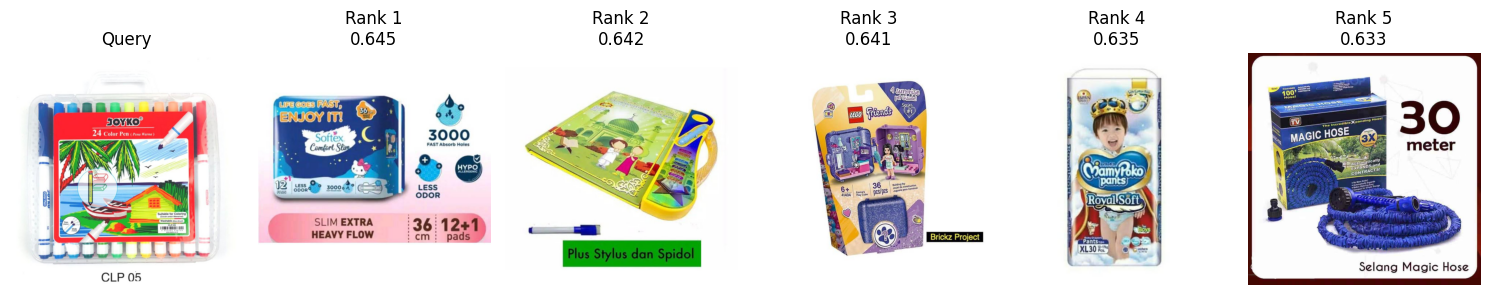

In [26]:
import matplotlib.pyplot as plt

display_indices = [query_index] + list(top_5)

plt.figure(figsize=(15, 3))

for position, idx in enumerate(display_indices):
    
    image = Image.open(image_dir + sample_images[idx]).convert("RGB")
    
    plt.subplot(1, 6, position + 1)
    plt.imshow(image)
    plt.axis("off")
    
    if position == 0:
        plt.title("Query")
    else:
        plt.title(f"Rank {position}\n{similarities_to_all[idx]:.3f}")

plt.tight_layout()
plt.show()

In [27]:
best_threshold = 0.40

image_pairs_analysis = image_pairs.copy()

image_pairs_analysis["prediction"] = (
    image_pairs_analysis["similarity"] >= best_threshold
).astype(int)

image_pairs_analysis["error_type"] = "Correct"

image_pairs_analysis.loc[
    (image_pairs_analysis["label"] == 0) &
    (image_pairs_analysis["prediction"] == 1),
    "error_type"
] = "False Positive"

image_pairs_analysis.loc[
    (image_pairs_analysis["label"] == 1) &
    (image_pairs_analysis["prediction"] == 0),
    "error_type"
] = "False Negative"

print(image_pairs_analysis["error_type"].value_counts())

error_type
Correct           2937
False Positive     151
False Negative     122
Name: count, dtype: int64


In [28]:
false_positives = image_pairs_analysis[
    image_pairs_analysis["error_type"] == "False Positive"
].sort_values("similarity", ascending=False)

print(false_positives[["idx1", "idx2", "similarity"]].head(5))

      idx1  idx2  similarity
2890  3884  4048    0.772892
1857  2490  2934    0.750698
2077  1435  1455    0.693091
1771  3834  4390    0.675439
1913   768  3006    0.667657


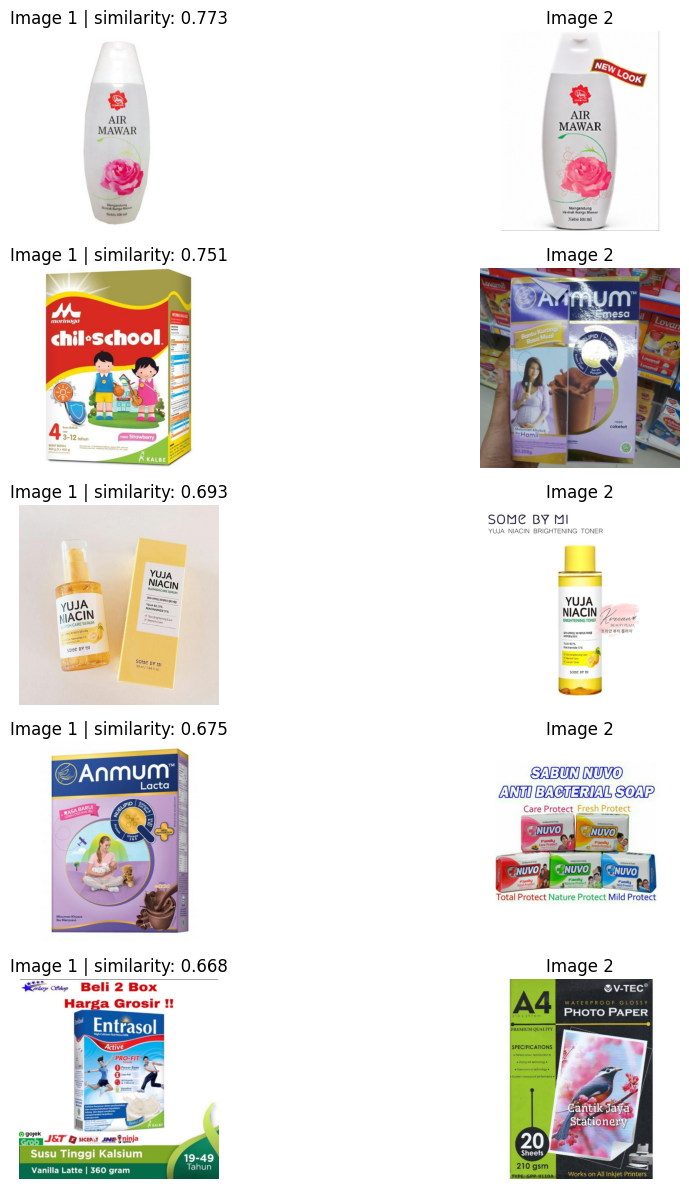

In [29]:
import matplotlib.pyplot as plt

fp_sample = false_positives.head(5)

plt.figure(figsize=(12, 12))

for row_num, (_, row) in enumerate(fp_sample.iterrows()):
    
    idx1 = int(row["idx1"])
    idx2 = int(row["idx2"])
    
    image1 = Image.open(
        image_dir + sample_images[idx1]
    ).convert("RGB")
    
    image2 = Image.open(
        image_dir + sample_images[idx2]
    ).convert("RGB")
    
    plt.subplot(5, 2, row_num * 2 + 1)
    plt.imshow(image1)
    plt.axis("off")
    plt.title(f"Image 1 | similarity: {row['similarity']:.3f}")
    
    plt.subplot(5, 2, row_num * 2 + 2)
    plt.imshow(image2)
    plt.axis("off")
    plt.title("Image 2")

plt.tight_layout()
plt.show()

In [30]:
false_negatives = image_pairs_analysis[
    image_pairs_analysis["error_type"] == "False Negative"
].sort_values("similarity")

print(false_negatives[["idx1", "idx2", "similarity"]].head(5))

      idx1  idx2  similarity
1168     5  1497    0.052053
1365  2080   590    0.154304
800     72  3360    0.159424
349   3526   649    0.160347
75    3165  2365    0.173378


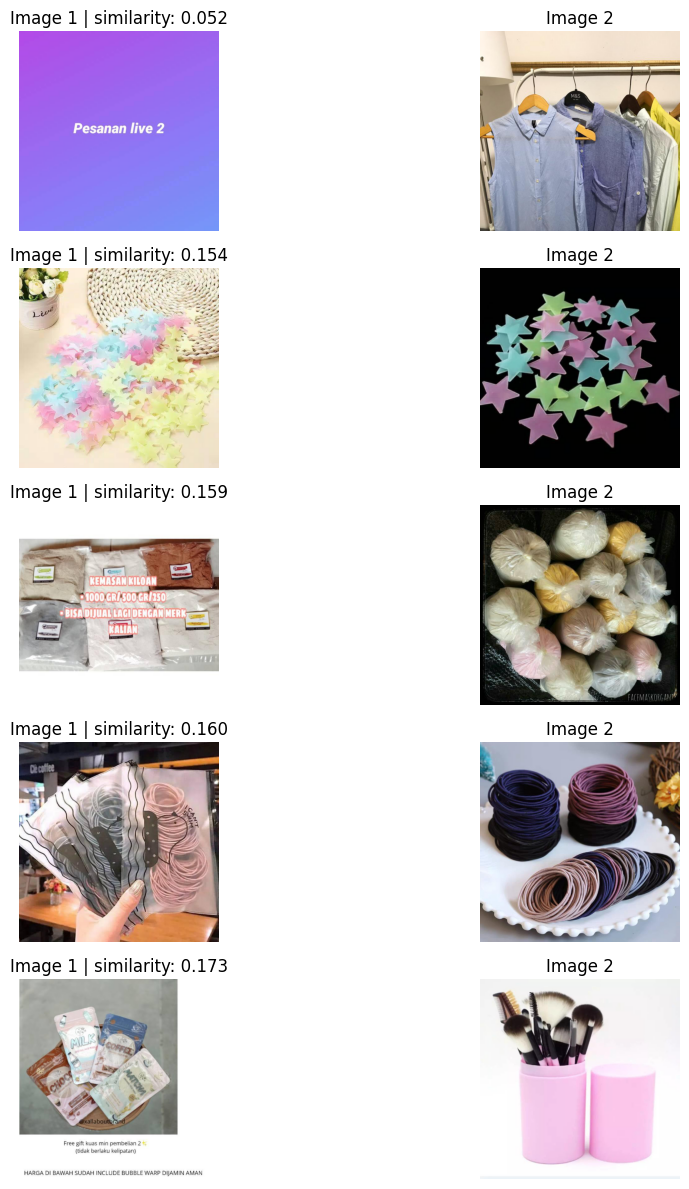

In [31]:
fn_sample = false_negatives.head(5)

plt.figure(figsize=(12, 12))

for row_num, (_, row) in enumerate(fn_sample.iterrows()):
    
    idx1 = int(row["idx1"])
    idx2 = int(row["idx2"])
    
    image1 = Image.open(
        image_dir + sample_images[idx1]
    ).convert("RGB")
    
    image2 = Image.open(
        image_dir + sample_images[idx2]
    ).convert("RGB")
    
    plt.subplot(5, 2, row_num * 2 + 1)
    plt.imshow(image1)
    plt.axis("off")
    plt.title(f"Image 1 | similarity: {row['similarity']:.3f}")
    
    plt.subplot(5, 2, row_num * 2 + 2)
    plt.imshow(image2)
    plt.axis("off")
    plt.title("Image 2")

plt.tight_layout()
plt.show()